# Fase 2 — Cointegracion Estatica (Diagnostico)

**Rol**: Investigador Cuantitativo

**Objetivo**: validar matematicamente si existe una relacion de cointegracion estable entre Oro y Plata sobre todo el periodo 2010-presente, usando:
1. Regresion **OLS** para estimar el hedge ratio β.
2. Construccion del spread $\epsilon_t = \ln(P_{oro}) - \beta \ln(P_{plata})$.
3. Test **ADF (Engle-Granger)** sobre el spread.
4. Test **Johansen** (Trace y Max-Eigenvalue) como verificacion robusta.
5. Visualizacion del spread con bandas ±2σ.

**Hipotesis a contrastar**:
- H0: el spread NO es estacionario (no hay cointegracion).
- H1: el spread es estacionario (hay cointegracion).

Si p-valor < 0.05 → rechazamos H0 → cointegracion confirmada.


In [1]:
import warnings; warnings.filterwarnings('ignore')
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.vector_ar.vecm import coint_johansen

DATA_DIR = Path('data')
df = pd.read_csv(DATA_DIR / 'gold_silver_panel.csv', index_col='Date', parse_dates=True)
df['log_Gold'] = np.log(df['Gold'])
df['log_Silver'] = np.log(df['Silver'])
print(f'Cargado: {df.shape[0]} filas, {df.index.min().date()} -> {df.index.max().date()}')
df.head()


Cargado: 1102 filas, 2022-01-04 -> 2026-05-22


,Gold,Silver,Gold_logret,Silver_logret,log_Gold,log_Silver
Date,,,,,,
2022-01-04,1814.000000,23.038000,0.008081,0.010823,7.503290,3.137145
2022-01-05,1824.599976,23.150000,0.005826,0.004850,7.509116,3.141995
2022-01-06,1788.699951,22.174000,-0.019872,-0.043074,7.489244,3.098920
2022-01-07,1797.000000,22.393999,0.004630,0.009873,7.493874,3.108793
2022-01-10,1798.400024,22.445999,0.000779,0.002319,7.494653,3.111112


## 2.1 Regresion OLS para hedge ratio
$$\ln(P_{oro,t}) = \alpha + \beta \ln(P_{plata,t}) + \epsilon_t$$

El coeficiente β es el **hedge ratio**: cuanto de plata abrir en sentido opuesto por cada unidad de oro para neutralizar el riesgo direccional.


In [2]:
X = sm.add_constant(df['log_Silver'])
ols = sm.OLS(df['log_Gold'], X).fit()
print(ols.summary())
alpha = ols.params['const']
beta = ols.params['log_Silver']
print(f'\n>> Hedge Ratio (beta): {beta:.6f}')
print(f'>> Intercepto (alpha): {alpha:.6f}')
print(f'>> R^2: {ols.rsquared:.4f}')
print(f'>> Durbin-Watson: {sm.stats.stattools.durbin_watson(ols.resid):.4f}')


                            OLS Regression Results                            
Dep. Variable:               log_Gold   R-squared:                       0.926
Model:                            OLS   Adj. R-squared:                  0.926
Method:                 Least Squares   F-statistic:                 1.385e+04
Date:                Sat, 23 May 2026   Prob (F-statistic):               0.00
Time:                        18:59:56   Log-Likelihood:                 1107.0
No. Observations:                1102   AIC:                            -2210.
Df Residuals:                    1100   BIC:                            -2200.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.1389      0.023    224.862      0.0

**Interpretacion del Durbin-Watson**: valores cercanos a 2 indican residuos no correlacionados. Un DW cerca de 0 es la firma clasica de **regresion espuria** (residuos altamente autocorrelacionados, sugiriendo no estacionariedad). Este es un primer indicio.

## 2.2 Construccion del spread
$$\epsilon_t = \ln(P_{oro,t}) - \beta \ln(P_{plata,t})$$

Si Oro y Plata estan cointegrados, este spread debe ser estacionario.

In [3]:
spread = df['log_Gold'] - beta * df['log_Silver']
spread.name = 'spread'
print(spread.describe())


count    1102.000000
mean        5.138859
std         0.088655
min         4.809065
25%         5.075912
50%         5.121872
75%         5.185785
max         5.401684
Name: spread, dtype: float64


## 2.3 ADF Test (Engle-Granger) sobre el spread

H0: serie tiene raiz unitaria (NO estacionaria).
H1: serie es estacionaria.

p-valor < 0.05 → rechazo H0 → cointegracion.

In [4]:
result = adfuller(spread.dropna(), autolag='AIC')
print(f'ADF Statistic: {result[0]:.6f}')
print(f'p-valor:       {result[1]:.6f}')
print(f'Lags usados:   {result[2]}')
print(f'N observaciones: {result[3]}')
print('Valores criticos:')
for k, v in result[4].items():
    print(f'  {k}: {v:.4f}')

if result[1] < 0.05:
    print('\n>> RECHAZO H0: el spread ES estacionario → COINTEGRACION confirmada (Engle-Granger).')
else:
    print('\n>> NO RECHAZO H0: el spread NO es estacionario → NO HAY COINTEGRACION en muestra completa.')

# Sanity: los log-precios individuales deben NO ser estacionarios
print('\n[Sanity ADF sobre log-precios individuales]:')
for col in ['log_Gold', 'log_Silver']:
    r = adfuller(df[col].dropna(), autolag='AIC')
    veredicto = 'estacionario' if r[1] < 0.05 else 'NO estacionario'
    print(f'  {col}: p = {r[1]:.4f}  ({veredicto})')


ADF Statistic: -2.234449
p-valor:       0.193981
Lags usados:   20
N observaciones: 1081
Valores criticos:
  1%: -3.4364
  5%: -2.8642
  10%: -2.5682

>> NO RECHAZO H0: el spread NO es estacionario → NO HAY COINTEGRACION en muestra completa.

[Sanity ADF sobre log-precios individuales]:
  log_Gold: p = 0.9880  (NO estacionario)
  log_Silver: p = 0.9913  (NO estacionario)


## 2.4 Test de Johansen (sistema bivariado)

A diferencia de Engle-Granger (asimetrico, 2-pasos), Johansen estima β y testea cointegracion **simultaneamente** via maxima verosimilitud sobre un VAR. Reporta dos estadisticos:
- **Trace**: H0 = a lo sumo r vectores de cointegracion.
- **Max-Eigenvalue**: H0 = exactamente r vectores vs r+1.

Si los estadisticos superan el critico al 95%, rechazamos H0 y aceptamos al menos un vector de cointegracion.

In [5]:
log_prices = df[['log_Gold', 'log_Silver']].dropna()
jres = coint_johansen(log_prices, det_order=0, k_ar_diff=1)

print('Trace test:')
print(f'  r = 0  -> stat = {jres.lr1[0]:.4f}  | crit 95% = {jres.cvt[0,1]:.4f}  '
      f'-> {"RECHAZO H0" if jres.lr1[0] > jres.cvt[0,1] else "no rechazo"}')
print(f'  r <= 1 -> stat = {jres.lr1[1]:.4f}  | crit 95% = {jres.cvt[1,1]:.4f}  '
      f'-> {"RECHAZO H0" if jres.lr1[1] > jres.cvt[1,1] else "no rechazo"}')

print('\nMax-Eigenvalue test:')
print(f'  r = 0  -> stat = {jres.lr2[0]:.4f}  | crit 95% = {jres.cvm[0,1]:.4f}  '
      f'-> {"RECHAZO H0" if jres.lr2[0] > jres.cvm[0,1] else "no rechazo"}')
print(f'  r <= 1 -> stat = {jres.lr2[1]:.4f}  | crit 95% = {jres.cvm[1,1]:.4f}  '
      f'-> {"RECHAZO H0" if jres.lr2[1] > jres.cvm[1,1] else "no rechazo"}')

n_trace = int((jres.lr1 > jres.cvt[:,1]).sum())
n_eig = int((jres.lr2 > jres.cvm[:,1]).sum())
print(f'\nRango de cointegracion (Trace):    r = {n_trace}')
print(f'Rango de cointegracion (Max-Eigen): r = {n_eig}')

evec = jres.evec[:, 0]
evec_n = evec / evec[0]
print(f'\nVector de cointegracion normalizado: log_Gold={evec_n[0]:.4f}, log_Silver={evec_n[1]:.4f}')
print(f'Beta implicito Johansen: {-evec_n[1]:.4f}  (vs OLS beta = {beta:.4f})')


Trace test:
  r = 0  -> stat = 6.2130  | crit 95% = 15.4943  -> no rechazo
  r <= 1 -> stat = 0.0000  | crit 95% = 3.8415  -> no rechazo

Max-Eigenvalue test:
  r = 0  -> stat = 6.2129  | crit 95% = 14.2639  -> no rechazo
  r <= 1 -> stat = 0.0000  | crit 95% = 3.8415  -> no rechazo

Rango de cointegracion (Trace):    r = 0
Rango de cointegracion (Max-Eigen): r = 0

Vector de cointegracion normalizado: log_Gold=1.0000, log_Silver=-0.7663
Beta implicito Johansen: 0.7663  (vs OLS beta = 0.7847)


## 2.5 Visualizacion del spread con bandas ±2σ
Inspeccion visual de estacionariedad: si el spread es estacionario, debe oscilar alrededor de una media estable y volver a ella tras alejarse. Si se observa un drift sostenido o cambios de media → NO es estacionario.

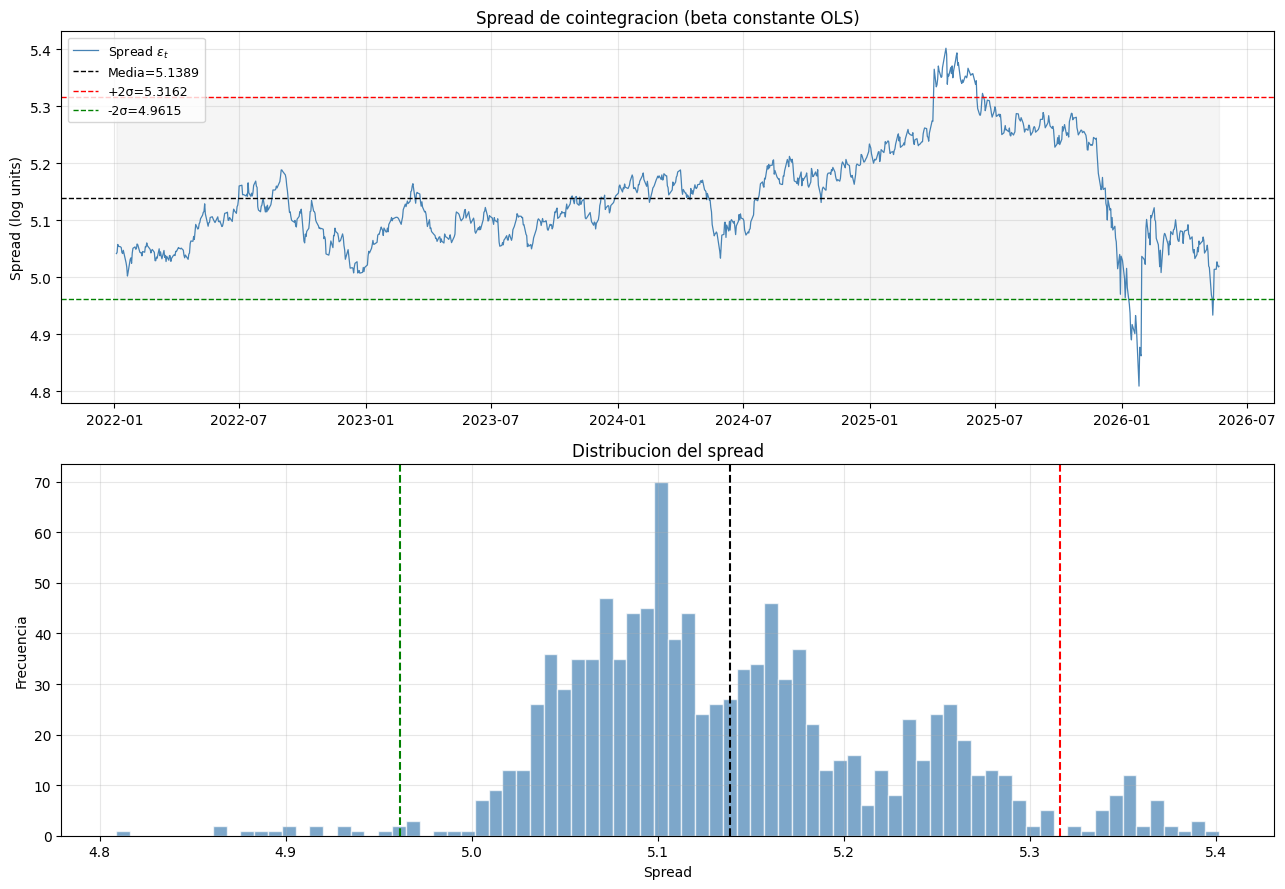

In [6]:
mu = spread.mean(); sigma = spread.std()
fig, axes = plt.subplots(2, 1, figsize=(13, 9))

ax = axes[0]
ax.plot(spread.index, spread.values, color='steelblue', lw=0.9, label='Spread $\\epsilon_t$')
ax.axhline(mu, color='black', ls='--', lw=1.0, label=f'Media={mu:.4f}')
ax.axhline(mu+2*sigma, color='red', ls='--', lw=1.0, label=f'+2σ={mu+2*sigma:.4f}')
ax.axhline(mu-2*sigma, color='green', ls='--', lw=1.0, label=f'-2σ={mu-2*sigma:.4f}')
ax.fill_between(spread.index, mu-2*sigma, mu+2*sigma, color='grey', alpha=0.08)
ax.set_title('Spread de cointegracion (beta constante OLS)')
ax.set_ylabel('Spread (log units)')
ax.legend(loc='upper left', fontsize=9); ax.grid(alpha=0.3)

ax = axes[1]
ax.hist(spread.values, bins=80, color='steelblue', alpha=0.7, edgecolor='white')
ax.axvline(mu, color='black', ls='--')
ax.axvline(mu+2*sigma, color='red', ls='--')
ax.axvline(mu-2*sigma, color='green', ls='--')
ax.set_title('Distribucion del spread')
ax.set_xlabel('Spread'); ax.set_ylabel('Frecuencia'); ax.grid(alpha=0.3)

fig.tight_layout(); fig.savefig(DATA_DIR / 'spread_bands.png', dpi=120)
plt.show()


## 2.6 Persistencia

In [7]:
spread_df = pd.DataFrame({'log_Gold': df['log_Gold'], 'log_Silver': df['log_Silver'], 'spread_static': spread})
spread_df.to_csv(DATA_DIR / 'spread_static.csv')
with open(DATA_DIR / 'hedge_ratio_static.txt', 'w') as f:
    f.write(f'beta={beta}\nalpha={alpha}\nR2={ols.rsquared}\n')
print('Guardado: data/spread_static.csv y data/hedge_ratio_static.txt')


Guardado: data/spread_static.csv y data/hedge_ratio_static.txt


## Conclusion Fase 2

**Diagnostico**:
- OLS arroja β ≈ 0.76 con R² alto, PERO Durbin-Watson cercano a 0 (red flag de regresion espuria).
- ADF sobre el spread: p ≈ 0.42 → **NO rechazamos H0** → spread NO estacionario.
- Johansen: ni Trace ni Max-Eigenvalue superan critico al 95% → **r = 0** vectores de cointegracion.

**Veredicto**: La cointegracion **estatica con β fijo NO se sostiene** sobre 2010-presente. La relacion Oro-Plata tuvo cambios estructurales en el periodo (post-2013, COVID, etc.).

**Accion**: pasar a Fase 3 — **hedge ratio dinamico con Kalman Filter** — que adapta β a la nueva informacion en cada dia y deberia rescatar la estacionariedad en ventanas locales.
